1. Introduction & Problem Statement

The Goal: Predict if a customer will say "Yes" or "No" to a term deposit (a type of savings account) after being contacted by a bank's marketing team.

The Business Value: Instead of calling 10,000 random people (expensive and annoying), the bank uses your model to call only the 1,000 people most likely to join.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Note: Sometimes these bank CSVs use a semicolon ';' instead of a comma ','
# if yours looks messy, add sep=';' inside the parenthesis.
df = pd.read_csv('bank.csv')

# 1. Display Structure
print("--- Dataset Shape ---")
print(df.shape)

# 2. Check for Missing Values (Data Integrity)
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 3. View the first few rows
df.head()

--- Dataset Shape ---
(11162, 17)

--- Missing Values ---
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
# 1. Label Encode the Target Variable (deposit)
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# 2. Identify all categorical columns (object type)
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns to encode:", list(categorical_columns))

# 3. Apply One-Hot Encoding
# This creates new columns for each category and drops the original text columns
df_final = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# 4. Show the new structure
print("\nNew Shape after One-Hot Encoding:", df_final.shape)
display(df_final.head())

Categorical columns to encode: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

New Shape after One-Hot Encoding: (11162, 43)


,age,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,job_entrepreneur,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,2343,5,1042,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
1,56,45,5,1467,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1270,5,1389,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
3,55,2476,5,579,1,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True
4,54,184,5,673,2,-1,0,1,False,False,...,False,False,False,True,False,False,False,False,False,True


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Define Features (X) and Target (y)
X = df_final.drop('deposit', axis=1) # All columns except the answer
y = df_final['deposit']              # Only the answer

# 2. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Random Forest
# n_estimators=100 means we are using 100 individual trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Predict and check Accuracy
y_pred = rf_model.predict(X_test)
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Random Forest Accuracy: 84.10%


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1166
           1       0.81      0.86      0.84      1067

    accuracy                           0.84      2233
   macro avg       0.84      0.84      0.84      2233
weighted avg       0.84      0.84      0.84      2233



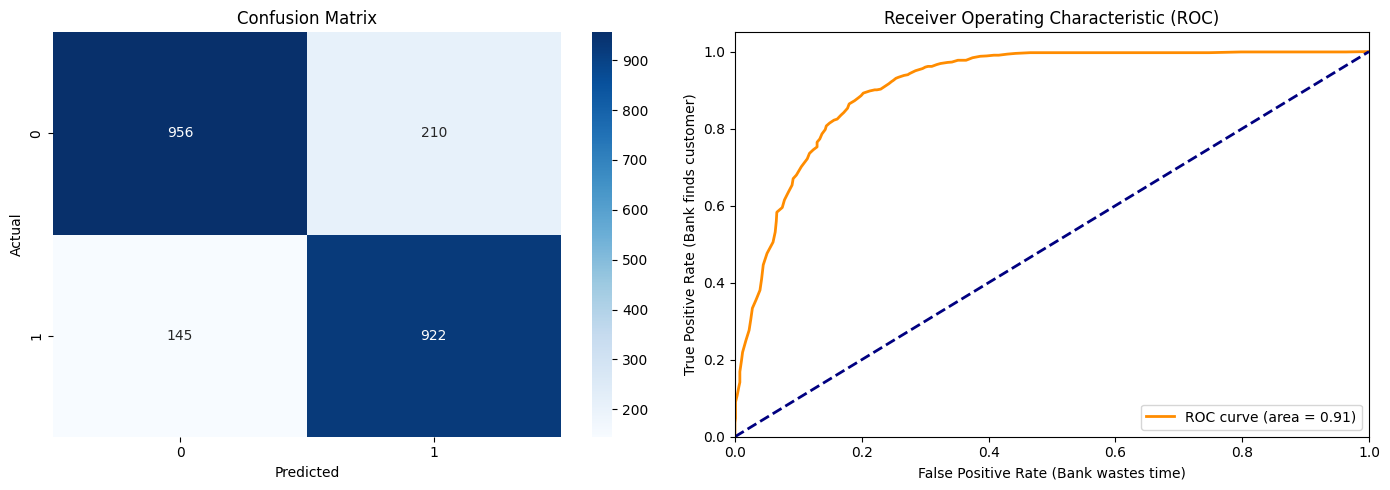

In [4]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Classification Report (F1-Score)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Heatmap
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# 3. ROC Curve
plt.subplot(1, 2, 2)
# Get the probability scores for the 'Yes' class
y_prob = rf_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Bank wastes time)')
plt.ylabel('True Positive Rate (Bank finds customer)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

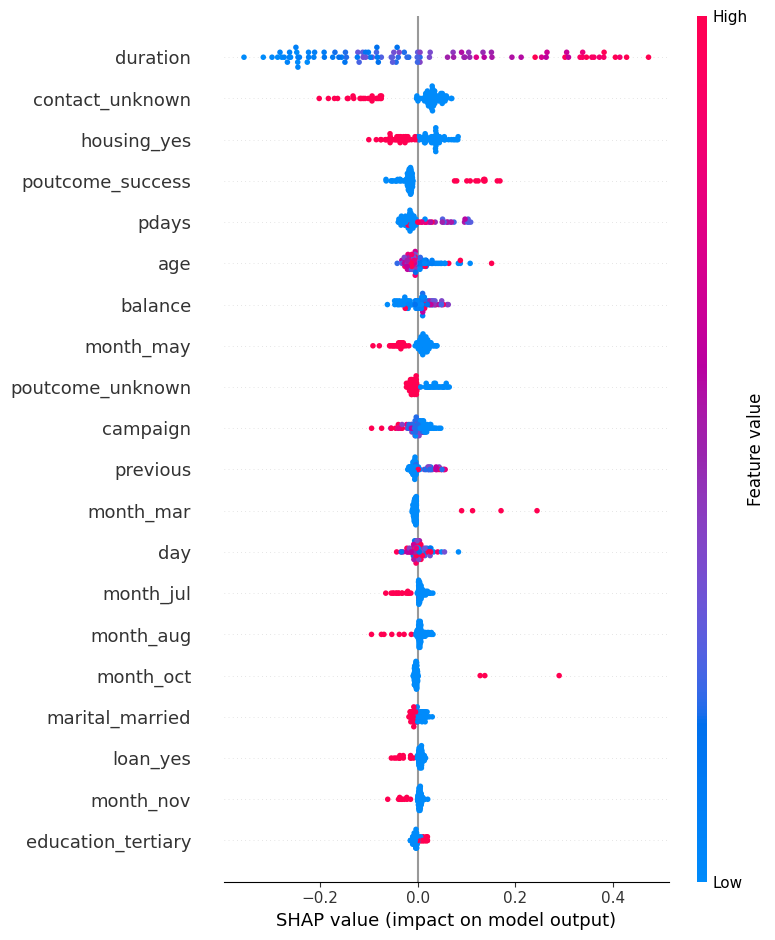

In [6]:
# 1. Install SHAP
!pip install shap

import shap

# 2. Create the SHAP Explainer
# We use a sample of the test data because SHAP can be computationally heavy
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test.iloc[:100])

# 3. Create a Summary Plot
# This shows which features are the most important across the whole dataset
shap.summary_plot(shap_values[..., 1], X_test.iloc[:100])


--- Explanation for Customer 1 ---


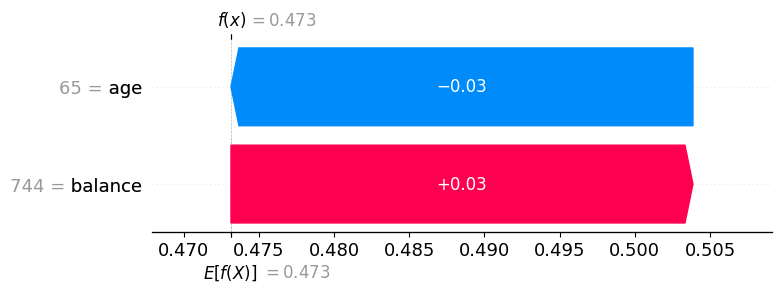


--- Explanation for Customer 2 ---


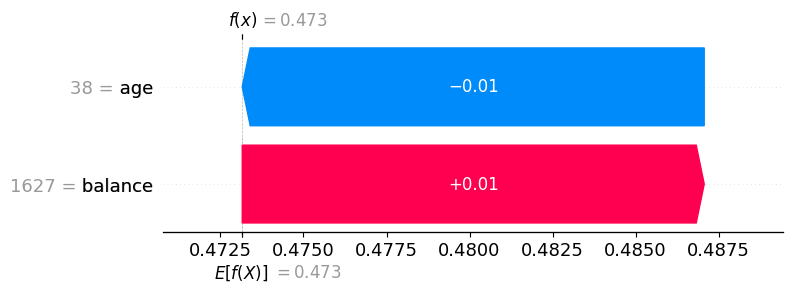


--- Explanation for Customer 3 ---


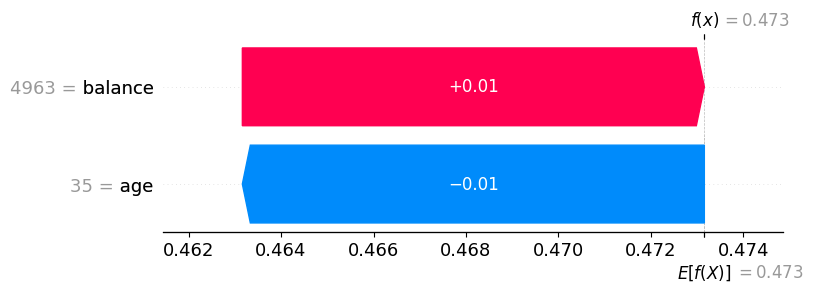


--- Explanation for Customer 4 ---


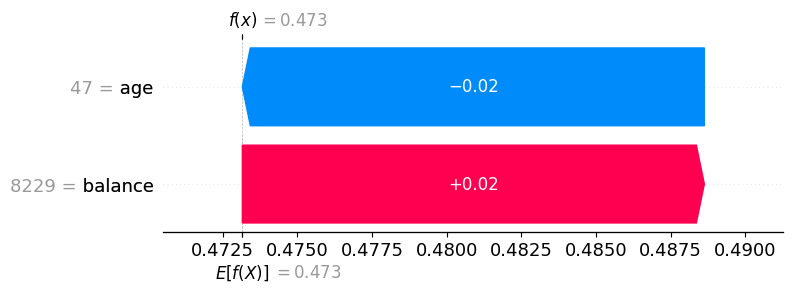


--- Explanation for Customer 5 ---


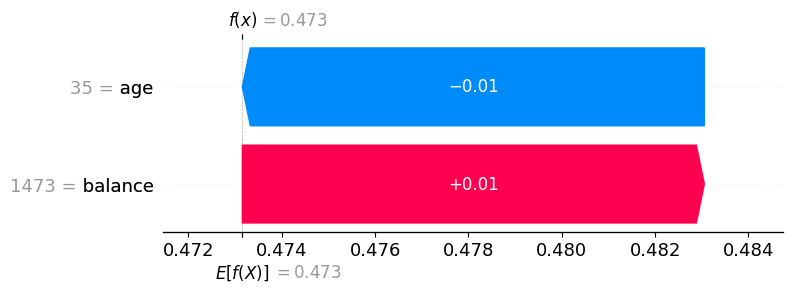

In [9]:
# Initialize javascript for SHAP visualization
shap.initjs()

# Explain the first 5 predictions of the test set
# We'll use a Waterfall plot as it's very clear for individual cases
for i in range(5):
    print(f"\n--- Explanation for Customer {i+1} ---")
    # Get SHAP values for the current instance across both classes
    single_instance_shap_values = explainer.shap_values(X_test.iloc[i])

    # Create an Explanation object for the positive class (index 1)
    # It needs the SHAP values, the base value (expected value for the class),
    # and the feature values for the instance.
    explanation_for_positive_class = shap.Explanation(
        values=single_instance_shap_values[1],
        base_values=explainer.expected_value[1],
        data=X_test.iloc[i]
    )
    shap.plots.waterfall(explanation_for_positive_class)